<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/06_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Statistical Machine Learning**

This notebook covers Statistical Machine Learning:
1. K-Nearest Neighbors (KNN)
2. Tree Models
3. Bagging and the Random Forest
4. Boosting
5. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

LOAN_DATA_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loan_data.csv.gz'
loan_data = pd.read_csv(LOAN_DATA_CSV)

loan_data['outcome'] = loan_data['outcome'].map({'paid off': 0, 'default': 1})

features = ['dti', 'payment_inc_ratio', 'borrower_score', 'revol_bal']
X = loan_data[features].dropna()
y = loan_data.loc[X.index, 'outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Pustaka berhasil diimpor dan dataset telah dibagi menjadi data latih dan uji.")

Pustaka berhasil diimpor dan dataset telah dibagi menjadi data latih dan uji.


## **1. K-Nearest Neighbors (KNN)**

K-Nearest Neighbors (KNN) is arguably the simplest and most intuitive machine learning algorithm in existence. It eschews mathematical equations entirely. When tasked with classifying a new, unseen record, KNN geometrically places that record into a multi-dimensional feature space. It then identifies the *K* closest historical records (the 'neighbors') using a distance metric, most commonly Euclidean distance. The new record is simply assigned to the majority class among its neighbors.

However, this conceptual simplicity hides a severe mathematical vulnerability: sensitivity to scale. Because KNN relies entirely on absolute geometric distance, a variable measured in tens of thousands (like annual income) will mathematically overwhelm a variable measured in decimals (like an interest rate), rendering the smaller variable utterly irrelevant. Therefore, standardization (converting all variables to Z-scores, where mean is 0 and standard deviation is 1) is absolutely mandatory before executing KNN. Furthermore, selecting the value of *K* represents a classic bias-variance tradeoff: a very low *K* captures excessive noise (high variance, overfitting), while a massive *K* blurs distinct boundaries (high bias, underfitting).

In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("--- Akurasi K-Nearest Neighbors (K=5) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_knn):.4f}")

--- Akurasi K-Nearest Neighbors (K=5) ---
Akurasi: 0.5875


## **2. Tree Models**

Tree models (specifically Decision Trees) depart entirely from both geometry and mathematical equations, utilizing a logical, rule-based approach. A decision tree operates via recursive partitioning. It evaluates all predictor variables to find the single threshold (e.g., 'borrower_score < 0.5') that most effectively splits the data into two highly homogeneous sub-groups. It repeats this process continuously down the branches until the terminal 'leaves' are as pure as possible.

To measure 'purity' mathematically, trees utilize metrics such as Gini Impurity or Information Gain (Entropy). Unlike regressions, tree models seamlessly handle highly non-linear relationships, are immune to extreme outliers, and do not strictly require dummy encoding for categorical variables. However, their fatal flaw is extreme variance. A fully grown decision tree will flawlessly memorize the training data—creating complex, absurdly specific rules (like a tree with a depth of 50)—resulting in catastrophic overfitting. Therefore, trees must be forcibly constrained ('pruned') by limiting their maximum depth.

--- Akurasi Decision Tree (Kedalaman Terbatas) ---
Akurasi: 0.6276



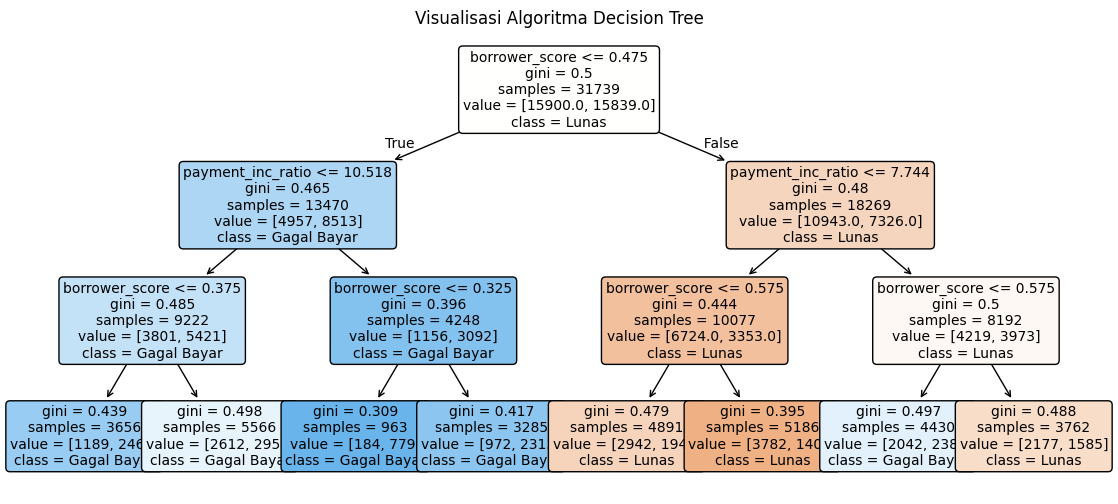

In [3]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print("--- Akurasi Decision Tree (Kedalaman Terbatas) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_tree):.4f}\n")

plt.figure(figsize=(14, 6))
plot_tree(tree_model, feature_names=features, class_names=['Lunas', 'Gagal Bayar'],
          filled=True, rounded=True, fontsize=10)
plt.title('Visualisasi Algoritma Decision Tree')
plt.show()

## **3. Bagging and the Random Forest**

Recognizing that single decision trees are fundamentally unstable and prone to overfitting, statisticians developed Ensemble Methods—the strategy of combining hundreds of weak models to create one exceptionally robust 'super model'. The foundation of this is 'Bagging' (Bootstrap Aggregating).

Bagging involves generating hundreds of different bootstrap samples (sampling with replacement) from the original dataset and training a distinct decision tree on each. The final prediction is simply the democratic average (or majority vote) of all the trees. The Random Forest algorithm elevates Bagging one step further: not only does it bootstrap the rows of data, but at each split in the tree, it randomly selects a small *subset of the predictor features*. This ingenious mathematical twist actively prevents highly dominant features from dictating the structure of every single tree, ensuring the ensemble consists of diverse, deeply decorrelated models, drastically reducing global variance.

--- Akurasi Random Forest (100 Pohon) ---
Akurasi: 0.5984



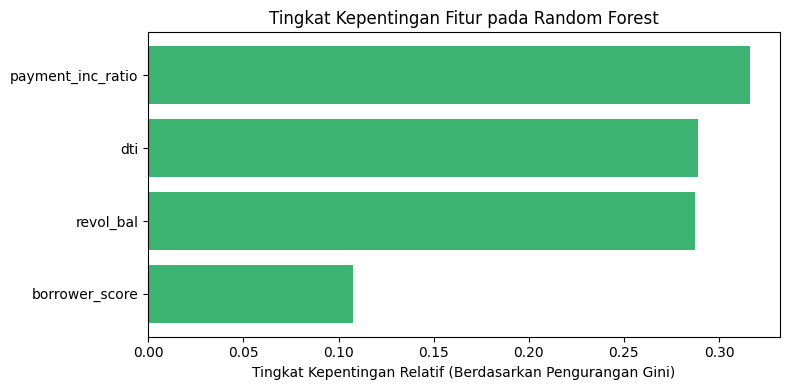

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("--- Akurasi Random Forest (100 Pohon) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf):.4f}\n")

importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 4))
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Tingkat Kepentingan Relatif (Berdasarkan Pengurangan Gini)')
plt.title('Tingkat Kepentingan Fitur pada Random Forest')
plt.tight_layout()
plt.show()

## **4. Boosting**

If Bagging is a parallel, democratic process where hundreds of independent trees vote simultaneously, Boosting is a sequential, evolutionary process. In Boosting algorithms (such as AdaBoost, Gradient Boosting, or XGBoost), trees are grown sequentially, with each new tree mathematically designed specifically to correct the catastrophic errors made by the previous ensemble of trees.

Gradient Boosting achieves this by fitting the new tree not to the original target outcome, but to the *residual errors* left over from the preceding trees. While Random Forest focuses heavily on reducing *variance* (overfitting), Boosting is hyper-focused on reducing *bias* (underfitting), making it theoretically capable of reaching higher absolute accuracy. However, because it aggressively chases residual errors, Boosting is highly susceptible to overfitting pure statistical noise if the 'learning rate' (the magnitude of correction each tree is allowed to make) is not strictly regularized.

In [5]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
print("--- Akurasi Gradient Boosting ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_gb):.4f}")

print("\nLaporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred_gb, target_names=['Lunas (0)', 'Gagal Bayar (1)']))

--- Akurasi Gradient Boosting ---
Akurasi: 0.6332

Laporan Klasifikasi Detail:
                 precision    recall  f1-score   support

      Lunas (0)       0.63      0.64      0.63      6771
Gagal Bayar (1)       0.64      0.63      0.63      6832

       accuracy                           0.63     13603
      macro avg       0.63      0.63      0.63     13603
   weighted avg       0.63      0.63      0.63     13603



## **5. Summary**

Chapter 6 marks the zenith of predictive modeling capabilities. We have traversed from the geometry-based K-Nearest Neighbors, to the logical partitioning of single Decision Trees, and finally to the immense power of Ensemble techniques via Bagging (Random Forest) and Boosting (Gradient Boosting).

The academic crux of this chapter is the immutable trade-off between predictive accuracy and model interpretability. Linear and Logistic regressions (Chapters 4 and 5) provide explicit coefficients that definitively explain the magnitude and direction of relationships, which is vital in regulated industries. Conversely, Random Forests and Boosting algorithms obscure the exact mechanical relationships within hundreds of opaque, interlocking trees. They cannot easily answer 'why' a specific prediction was made, but their algorithmic capability to independently map incredibly complex, non-linear feature interactions generally makes them the undisputed champions of raw predictive accuracy.